## CONUS GHCND TXx Extreme-Value Analysis with Gen_ncglized Extreme Value Modeling

This notebook fits Gen_ncglized Extreme Value (GEV) distributions to the Annual Maximum Daily Temperature (TXx) time series from CONUS GHCND stations. The analysis includes location and scale parameter variations with climate covariates, cross-validation for model assessment, and bootstrap confidence intervals for derived quantities (return levels and parameter changes).

In [59]:
itest='CONUSlite_TXx_GHCNDvsNClimGrid_ij_glostLocSca_extremes_gev_CV_CI'

### Configuration and Environment Setup

Set up test name identifier and configure parallel processing threads for numerical computation.

In [60]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"]="8"

In [61]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
from copy import copy
import geopandas as gpd
from shapely.geometry import Point

In [62]:
import datetime
from matplotlib import cm

In [63]:
import rpy2
from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv


%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [64]:
%R Sys.setenv(OMP_NUM_THREADS = 8)
%R Sys.setenv(OPENBLAS_NUM_THREADS = 8)
%R Sys.setenv(MKL_NUM_THREADS = 8)

1


In [65]:
extRemes = importr("extRemes")
twosamples = importr("twosamples")
dplyr = importr("dplyr")
%R source("R_utils.R")

In [66]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [67]:
import warnings
warnings.filterwarnings('ignore')
%R options( warn = -1 )

In [68]:
def find_nearest_valid(arr, lon, lat, radius=1):
    """Find the nearest valid value in a dataset for a given variable and coordinates."""
    # Select a subset of points within a certain radius
    subset = arr.sel(lon=slice(lon-radius, lon+radius), lat=slice(lat-radius, lat+radius))
    # Calculate the Euclidean distance to the points in the subset
    dist = np.sqrt((subset.lon - lon)**2 + (subset.lat - lat)**2)
    # Create a new dataset that only includes valid values
    valid_subset = subset.where(~np.isnan(subset), drop=True)
    # Find the coordinates of the valid point with the smallest distance
    min_dist_coords = dist.where(dist == dist.where(~np.isnan(valid_subset)).min(), drop=True)
    nearest_lon = min_dist_coords.lon.values.item()
    nearest_lat = min_dist_coords.lat.values.item()
    # Select the nearest valid value
    nearest = valid_subset.sel(lon=nearest_lon, lat=nearest_lat)
    return nearest.to_dataframe().reset_index()
    arr_series = arr.sel(lon=lon, lat=lat,method="nearest").to_dataframe().reset_index()

### Data Loading

Load Annual Maximum Daily Temperature (TXx) from GHCND stations, NClimGrid-derived TXx for spatial comparison, GLOST climate covariates, and geographic data defining the Washington analysis domain.

In [69]:
Tstations = ['USC00452675','USC00456534','USC00045933','USC00046074','USC00028619','USC00025924','USC00307134','USC00306774']
Tstates = ['WA','WA', 'CA', 'CA','AZ','AZ','NY','NY']

In [70]:
yearb = 1979
yeare = 2025
time = np.arange(yearb, yeare + 1, 1)

lon_min = 236
lon_max = 295
lat_min = 22
lat_max = 50

In [71]:
elevation = xr.DataArray(np.zeros((len(Tstations),)), coords=[Tstations], dims=["station"])
longitude = xr.DataArray(np.zeros((len(Tstations),)), coords=[Tstations], dims=["station"])
latitude = xr.DataArray(np.zeros((len(Tstations),)), coords=[Tstations], dims=["station"])
name = xr.DataArray(np.zeros((len(Tstations),)).astype('U100'), coords=[Tstations], dims=["station"])
TXx = xr.DataArray(np.zeros((len(Tstations),len(time))), coords=[Tstations, time], dims=["station", "time"])

In [72]:
for istation, state in zip(Tstations, Tstates):
    print(f'Processing station: {istation} in state: {state}')
    ifile=f'~/data/TXx/GHCND_TXx_utils_{state}.nc'
    ds = xr.open_dataset(ifile)
    TXx.loc[{'station':istation}] = ds['TXx'].sel(station=istation,time=time)
    name.loc[{'station':istation}] = ds['name'].sel(station=istation)
    elevation.loc[{'station':istation}] = ds['elevation'].sel(station=istation)
    longitude.loc[{'station':istation}] = ds['longitude'].sel(station=istation)
    latitude.loc[{'station':istation}] = ds['latitude'].sel(station=istation)
units='°C'

Processing station: USC00452675 in state: WA
Processing station: USC00456534 in state: WA
Processing station: USC00045933 in state: CA
Processing station: USC00046074 in state: CA
Processing station: USC00028619 in state: AZ
Processing station: USC00025924 in state: AZ
Processing station: USC00307134 in state: NY
Processing station: USC00306774 in state: NY


In [73]:
ds = TXx.to_dataset(name='TXx')
ds = ds.merge({'name': name, 'elevation': elevation, 'longitude': longitude, 'latitude': latitude})

In [74]:
ifile='/Volumes/Data/CMIP6_Large_Ensembles/NClimGrid/AnnualMaximumDailyTmax.NClimGrid.1951-2025.nc4'
dsae = xr.open_dataset(ifile)

In [75]:
dsae['TXx'].attrs

{'units': 'degC',
 'standard_name': 'air_temperature',
 'var_desc': 'Daily Maximum Temperature',
 'valid_range': array([-100.,  100.], dtype=float32),
 'long_name': 'Annual Maximum Daily Maximum Temperature at 2m',
 'statistic': 'Daily Maxiumum',
 'dataset': 'NOAA/NCEI Nclim',
 'level_desc': 'Surface'}

In [76]:

ifile='/Volumes/Data/CMIP6_Large_Ensembles/NClimGrid/AnnualMaximumDailyTmax.NClimGrid.1951-2025.nc4'
dsae = xr.open_dataset(ifile)
dsae = dsae.sel(time=slice(yearb,yeare))
dsae['lon'] = dsae['lon']
dsae['time'] = np.arange(yearb,yeare+1,1)


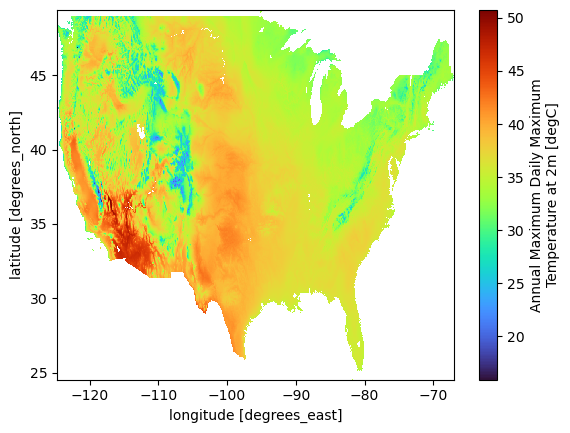

In [77]:
dsae['TXx'].mean('time').plot(cmap='turbo')

In [78]:
dsae['TXx'] = dsae['TXx']*9/5 + 32 # Celsius to Fahrenheit

ds['TXx'] = ds['TXx']*9/5 + 32 # Celsius to Fahrenheit

units = f'$\degree F$'

In [79]:

fileGLOST = '~/data/AFI/annual_LOESS_NOAA_GLOST_anomaly_1850_2025.nc'
ds_glost = xr.open_dataset(fileGLOST)
ann_glost = ds_glost['GLOST']
ds = ds.merge({'glost':ann_glost.sel(time=ds.time)}) 
ds = ds.sel(time=slice(yearb,yeare))  
glost_units = f'$\degree$ C'
units_cov = glost_units

### Analysis Parameters and Output Array Initialization

Define return periods, quantiles, cross-validation splits, and random seed. Initialize xarray output arrays to store GEV parameters (location, scale, shape), return levels, goodness-of-fit metrics (AIC/BIC), p-values for nested model tests, cross-validation scores, and bootstrap confidence intervals.

In [80]:
return_periods = [2, 5, 10, 20, 50, 100]
%R rp <- c(2, 5, 10, 20, 50, 100)
Tquantile = [0.05,0.5,0.95] # alpha=0.1
K = 4 # number of splits for Cross-Validation
%R -i K 
n = 300
%R -i n # Bootstrap iterations

In [81]:
%R set.seed(1)

### Station Selection

Select stations with at least 70% data coverage over the analysis period.

In [82]:
xxx = xr.where(np.isnan(ds['TXx'].sel(time=slice(yearb,yeare+1)))==False,1,0)
Tstations = np.where(xxx.sum('time')>=(yeare+1-yearb)*70/100.)[0]
Tstations = ds['station'].isel(station=Tstations).data

In [83]:
vals,idx = np.unique(Tstates, return_index=True)
vals[np.argsort(idx)]

array(['WA', 'CA', 'AZ', 'NY'], dtype='<U2')

Processing state: WA
station EVERETT is at lon: -122.195, lat: 47.97528
Nearest valid NClimGrid point is at lon: -122.1874998, lat: 47.97916854
station PLAIN is at lon: -120.65881, lat: 47.75838
Nearest valid NClimGrid point is at lon: -120.64583301, lat: 47.77083519


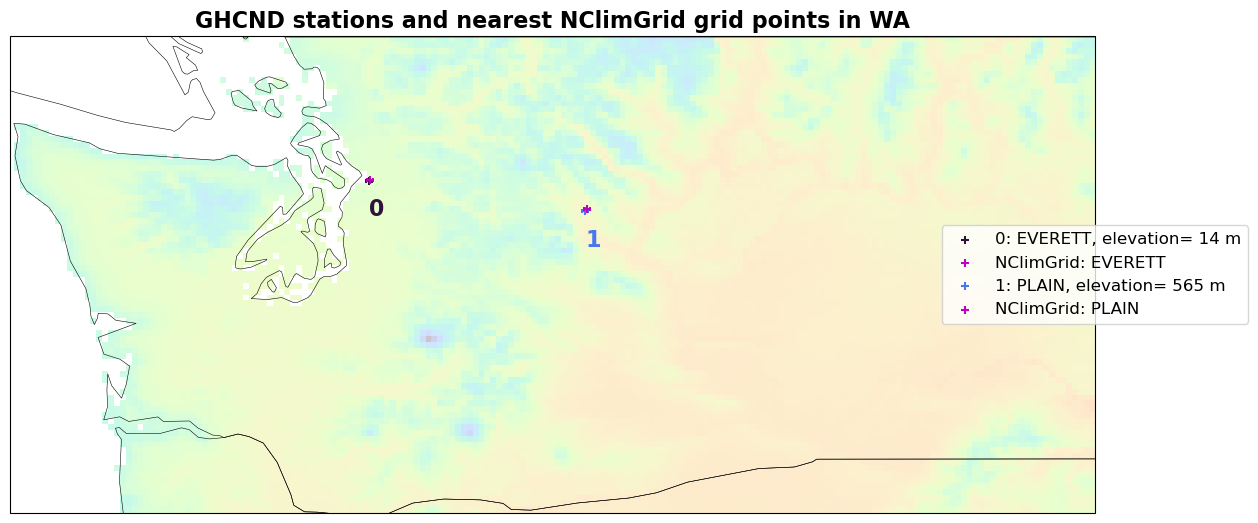

Processing state: CA
station MOUNT HAMILTON is at lon: -121.63473, lat: 37.34336
Nearest valid NClimGrid point is at lon: -121.64583309, lat: 37.35416769
station NAPA STATE HOSPITAL is at lon: -122.2647, lat: 38.2777
Nearest valid NClimGrid point is at lon: -122.27083314, lat: 38.27083443


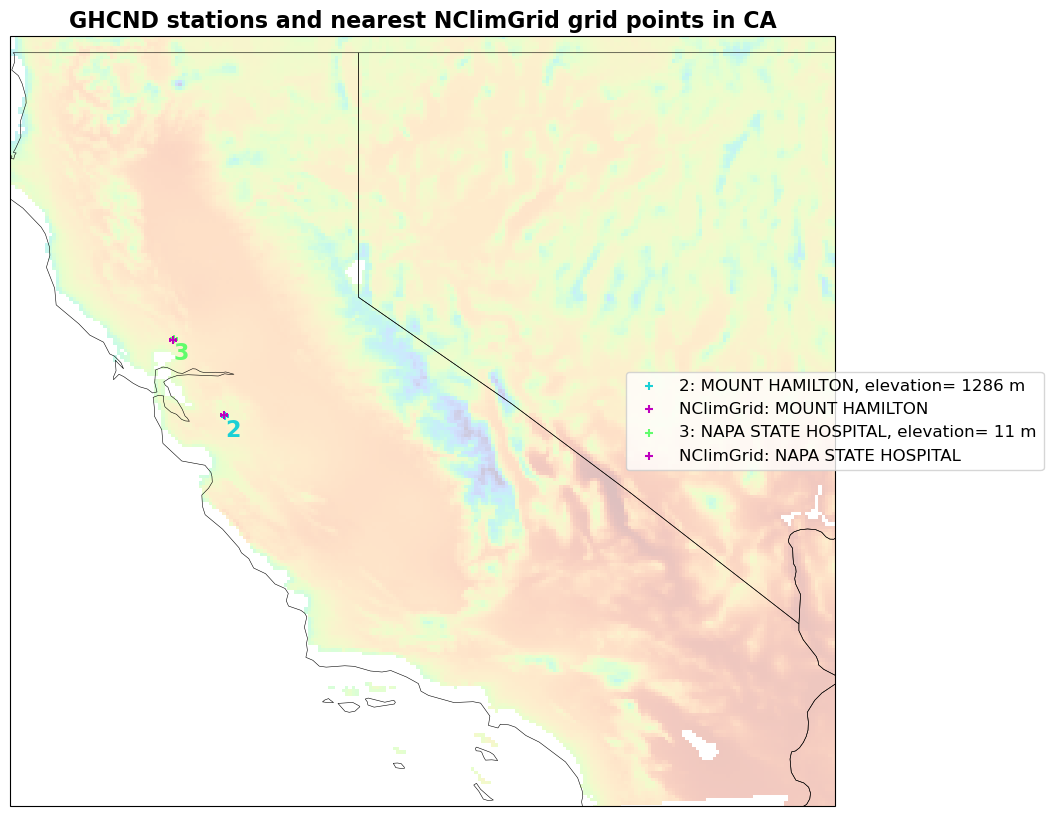

Processing state: AZ
station TOMBSTONE is at lon: -110.0686, lat: 31.7119
Nearest valid NClimGrid point is at lon: -110.06249883, lat: 31.72916724
station NOGALES 6 N is at lon: -110.968, lat: 31.4554
Nearest valid NClimGrid point is at lon: -110.97916557, lat: 31.43750055


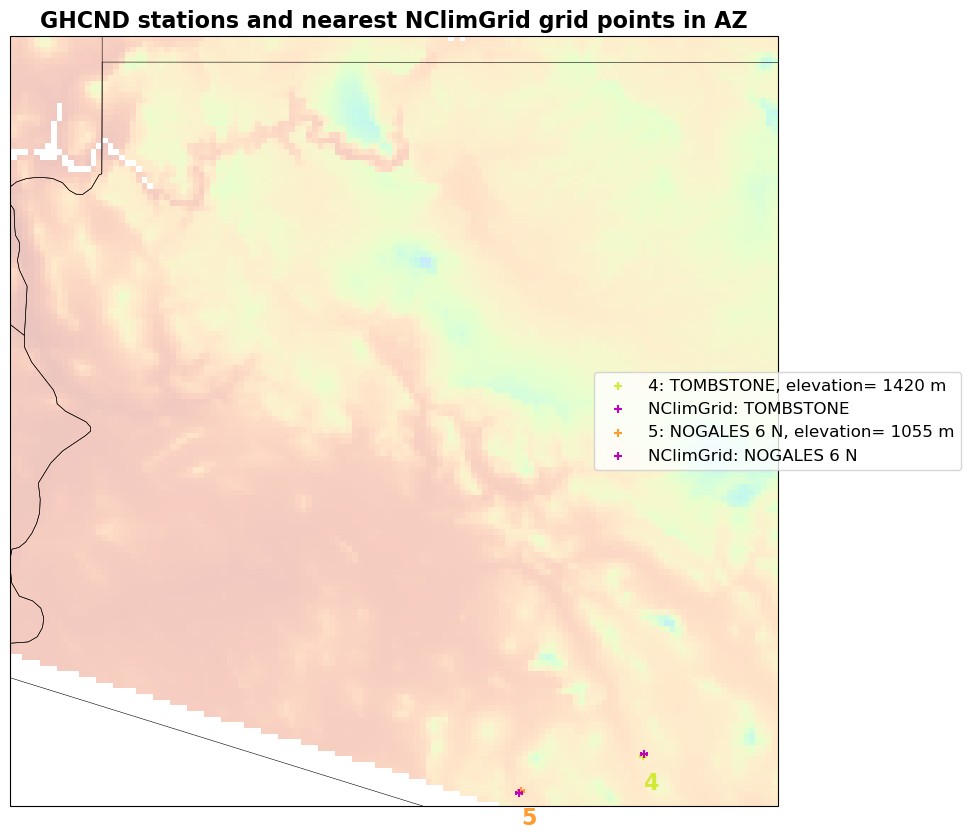

Processing state: NY
station RIVERHEAD RESEARCH FARM is at lon: -72.71612, lat: 40.96245
Nearest valid NClimGrid point is at lon: -72.72916251, lat: 40.93750131
station PORT JERVIS is at lon: -74.6905, lat: 41.3891
Nearest valid NClimGrid point is at lon: -74.687496, lat: 41.39583468


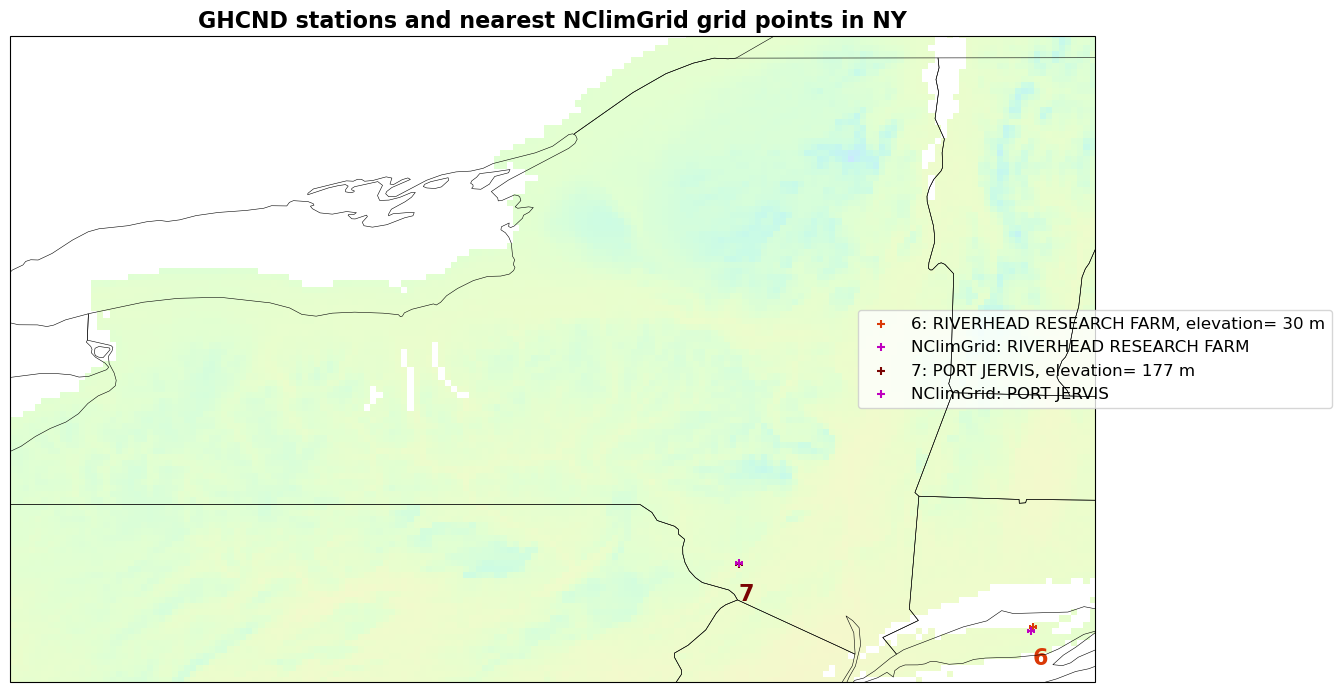

In [84]:
radius = 1.0
colors=cm.get_cmap('turbo',len(Tstations))
ij=0
vals,idx = np.unique(Tstates, return_index=True)
for istate in vals[np.argsort(idx)]:
  print(f'Processing state: {istate}')
  Tstations_state = [station for station, state in zip(Tstations, Tstates) if state == istate]
  
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,10),subplot_kw={'projection':ccrs.PlateCarree()})
  fig.subplots_adjust(hspace=1.15)
  ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  dsae['TXx'].mean('time').plot(ax=ax,cmap='turbo',add_colorbar=False,alpha=0.25)
  for istation in Tstations_state:
    ilon = longitude.sel(station=istation).data
    ilat = latitude.sel(station=istation).data
    iname = name.sel(station=istation).data.item().split(',')[0]
    ielevation = elevation.sel(station=istation).data.item()
    if not dsae['TXx'].sel(lon=slice(ilon-radius, ilon+radius), lat=slice(ilat-radius, ilat+radius)).mean('time').isnull().all():
      valid_ncg = find_nearest_valid(dsae['TXx'], ilon, ilat, radius=radius)
      print(f'station {iname} is at lon: {ilon}, lat: {ilat}')
      print(f'Nearest valid NClimGrid point is at lon: {valid_ncg["lon"].values[0].item()}, lat: {valid_ncg["lat"].values[0].item()}')

    ax.scatter(ilon,ilat,marker='+',s=40,color=colors(ij),label=f'{ij}: {iname}, elevation= {ielevation:.0f} m')  
    ax.scatter(valid_ncg["lon"].values[0].item(), valid_ncg["lat"].values[0].item(), marker='+', s=40, color='m', label=f'NClimGrid: {iname}')
    ax.text(ilon,ilat-0.25,ij,color=colors(ij),fontsize=16,fontweight='bold')
    ij = ij + 1
  if istate == 'WA':
    ax.set_extent([-124.73694, -117.04768, 45.61901, 49.0], crs=ccrs.PlateCarree())     
  elif istate == 'CA':
    ax.set_extent([-124.2661, -114.17137, 32.56797, 41.9919], crs=ccrs.PlateCarree())
  elif istate == 'AZ':
    ax.set_extent([-114.71667, -109.08333, 31.345, 36.9953], crs=ccrs.PlateCarree())
  elif istate == 'NY':
    ax.set_extent([-79.58556, -72.2977, 40.59389, 44.93341], crs=ccrs.PlateCarree())   
  ax.set_title(f'GHCND stations and nearest NClimGrid grid points in {istate}',fontsize=16,fontweight='bold')  
  plt.legend(loc='center',fontsize=12,bbox_to_anchor=(1., 0.5), borderaxespad=0.)
  plt.show()

**Figure caption.** Map of selected GHCND stations (marked with magenta plus signs) overlaid on the mean location parameter from NClimGrid-derived GEV fits. Station indices are labeled to identify each location in the analysis domain.

### Model Specification

Define the fevd (Fit an Extreme Value Distribution) formula with linear location and scale parameters as functions of GLOST climate covariate. 

In [85]:
%R fevd_options <- "type='GEV', method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"

array(["type='GEV', method='MLE', initial = initial_vals, location.fun = ~ glost, scale.fun = ~ glost"],
      dtype='<U93')

In [86]:
compute_CI = True # Turn on Confidence Interval computation

In [87]:
print(datetime.datetime.now())

2026-09-10 13:33:45.912111


### Main Processing Loop: Station-by-Station GEV Fitting

For each selected GHCND station, extract the TXx time series, compare with ERA5 nearest-neighbor values, fit GEV distributions with GLOST covariate, perform 5-fold cross-validation for model diagnostics, compute bootstrap confidence intervals (optional), and populate the output arrays with estimates and uncertainty measures.

#########################################
Processing station EVERETT, WA US at lon=-122.195, lat=47.97528, elevation=14 m
Nearest valid NClimGrid point is at lon= -122.1874998, lat= 47.97916854
#########################################


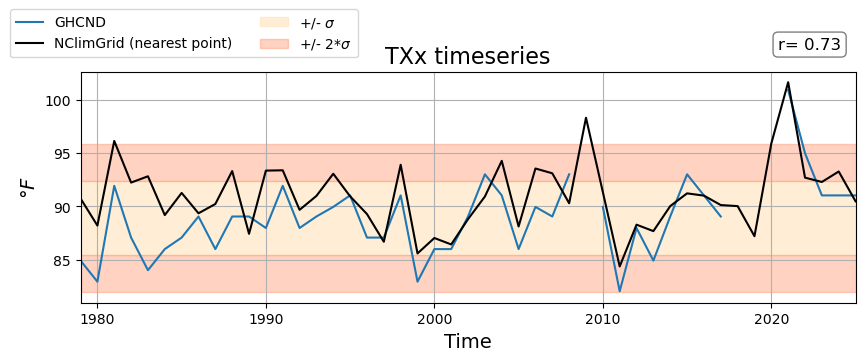

GEV model fitted: GHCND data


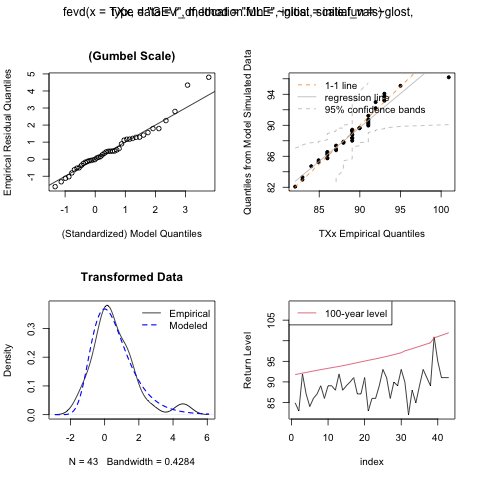

GEV model fitted: NclimGrid data


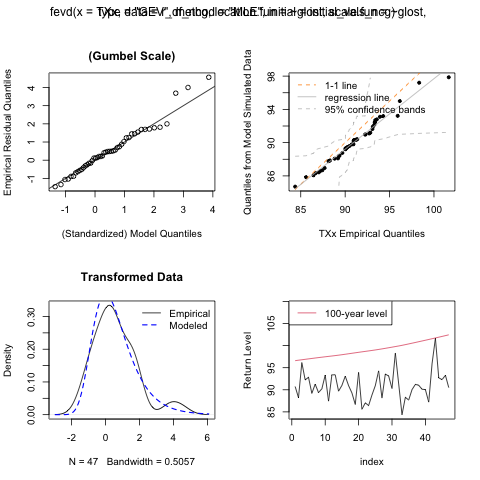

#########################################
Processing station PLAIN, WA US at lon=-120.65881, lat=47.75838, elevation=565 m
Nearest valid NClimGrid point is at lon= -120.64583301, lat= 47.77083519
#########################################


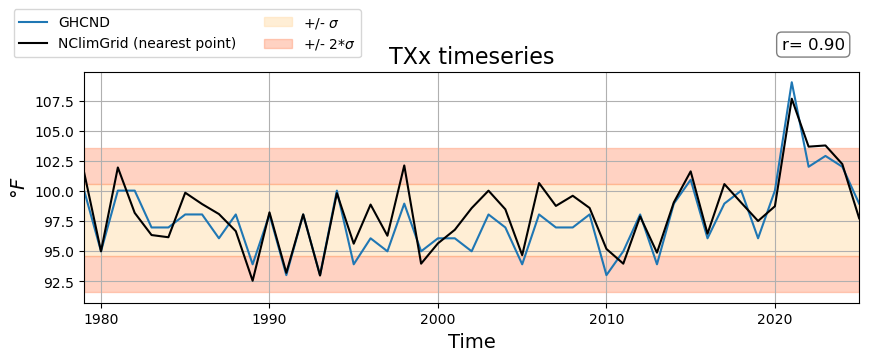

GEV model fitted: GHCND data


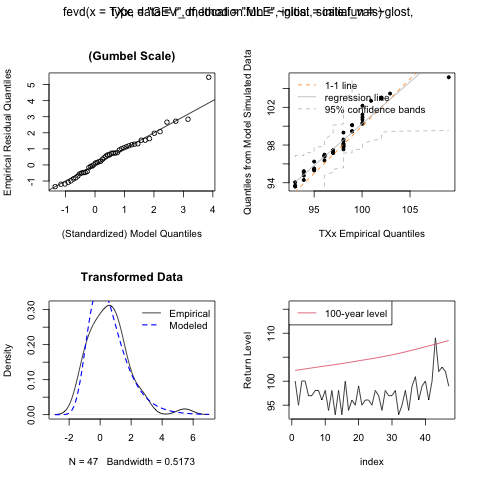

GEV model fitted: NclimGrid data


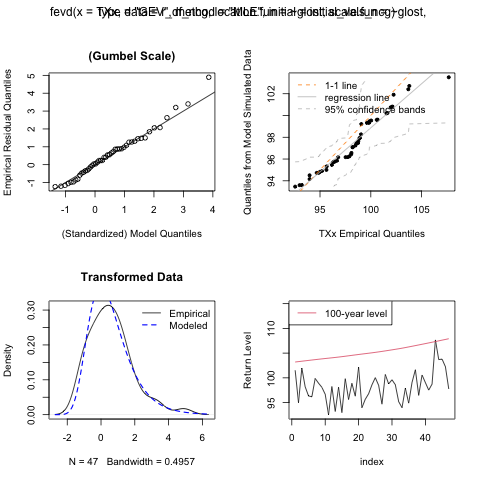

#########################################
Processing station MOUNT HAMILTON, CA US at lon=-121.63473, lat=37.34336, elevation=1286 m
Nearest valid NClimGrid point is at lon= -121.64583309, lat= 37.35416769
#########################################


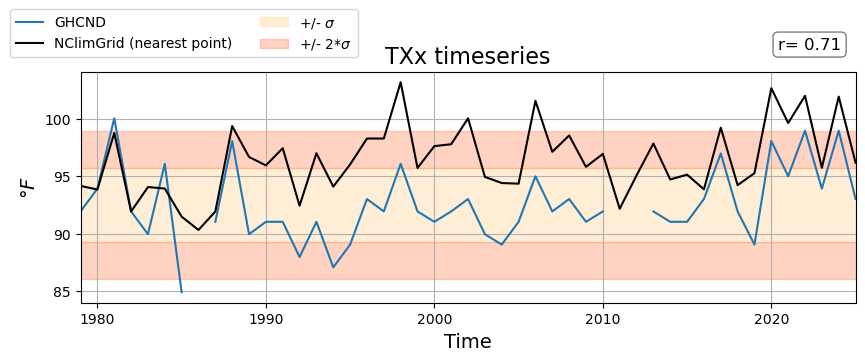

GEV model fitted: GHCND data


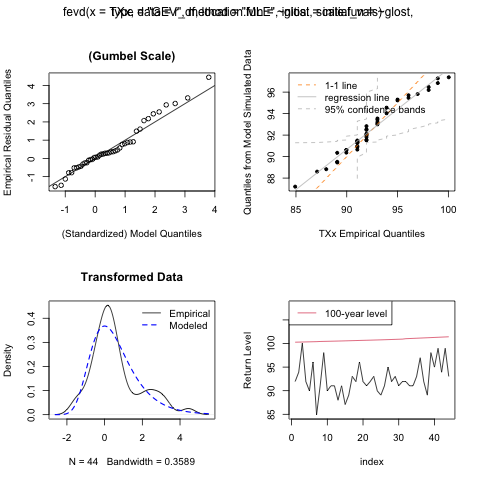

GEV model fitted: NclimGrid data


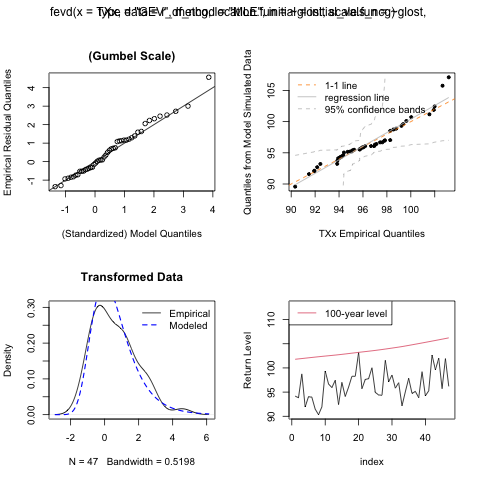

#########################################
Processing station NAPA STATE HOSPITAL, CA US at lon=-122.2647, lat=38.2777, elevation=11 m
Nearest valid NClimGrid point is at lon= -122.27083314, lat= 38.27083443
#########################################


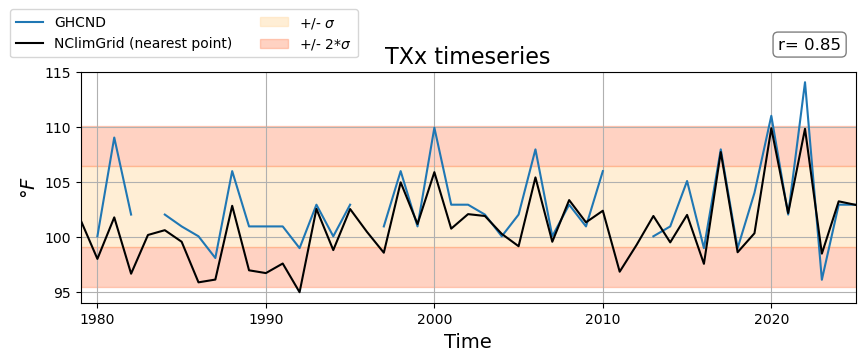

GEV model fitted: GHCND data


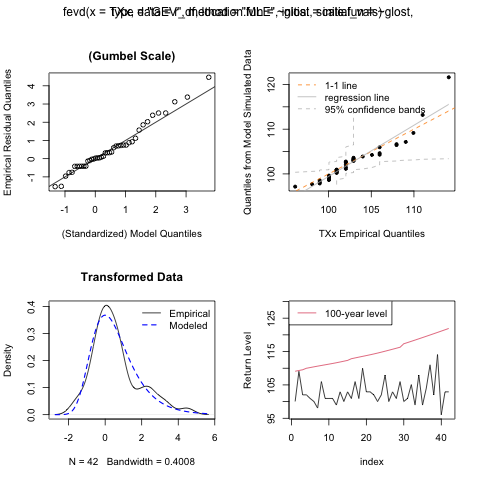

GEV model fitted: NclimGrid data


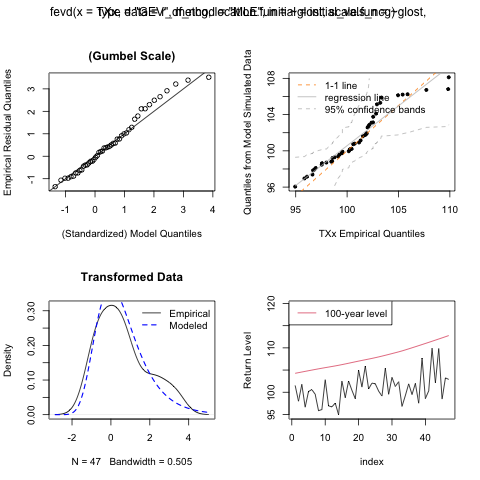

#########################################
Processing station TOMBSTONE, AZ US at lon=-110.0686, lat=31.7119, elevation=1420 m
Nearest valid NClimGrid point is at lon= -110.06249883, lat= 31.72916724
#########################################


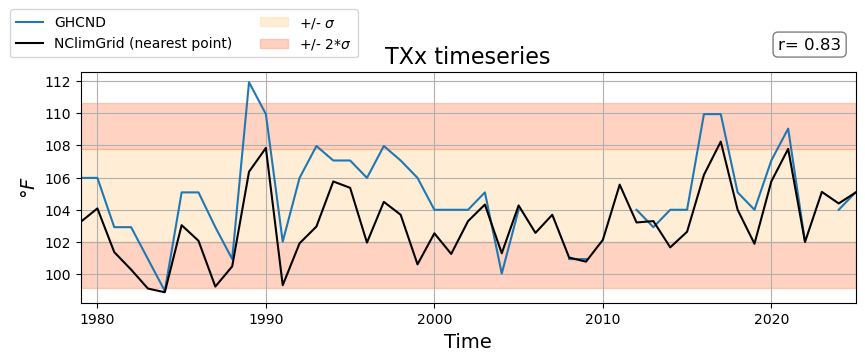

GEV model fitted: GHCND data


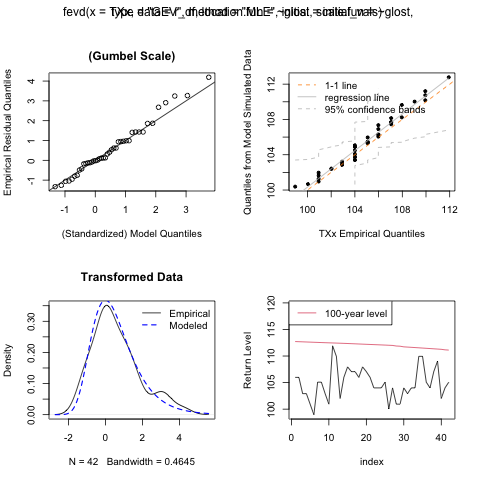

GEV model fitted: NclimGrid data


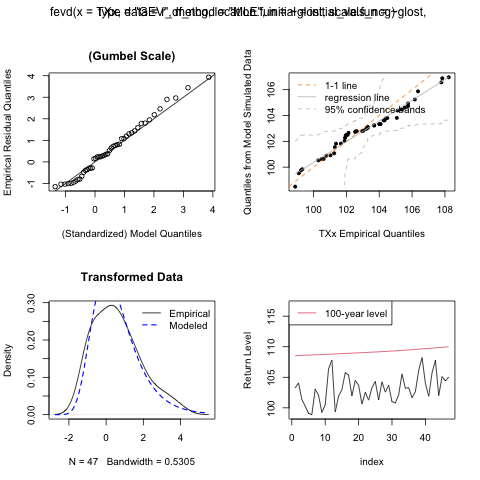

#########################################
Processing station NOGALES 6 N, AZ US at lon=-110.968, lat=31.4554, elevation=1055 m
Nearest valid NClimGrid point is at lon= -110.97916557, lat= 31.43750055
#########################################


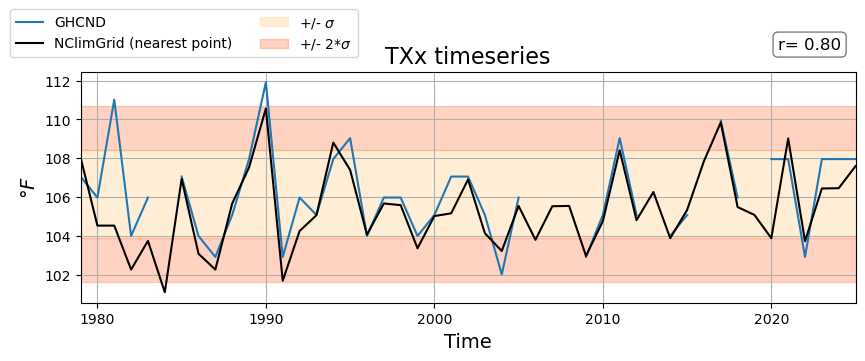

GEV model fitted: GHCND data


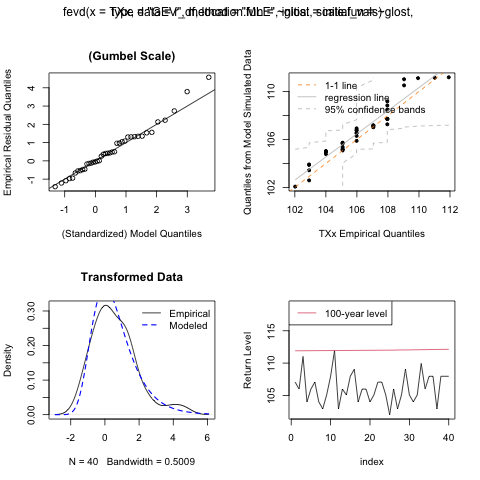

GEV model fitted: NclimGrid data


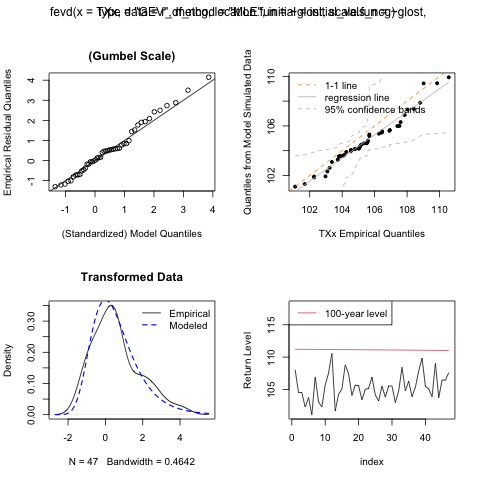

#########################################
Processing station RIVERHEAD RESEARCH FARM, NY US at lon=-72.71612, lat=40.96245, elevation=30 m
Nearest valid NClimGrid point is at lon= -72.72916251, lat= 40.93750131
#########################################


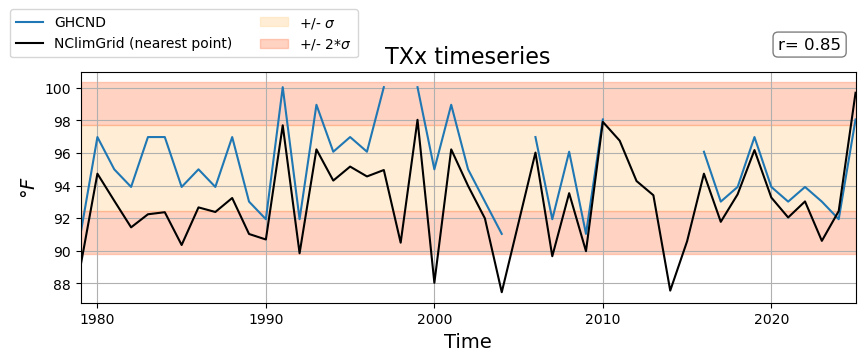

GEV model fitted: GHCND data


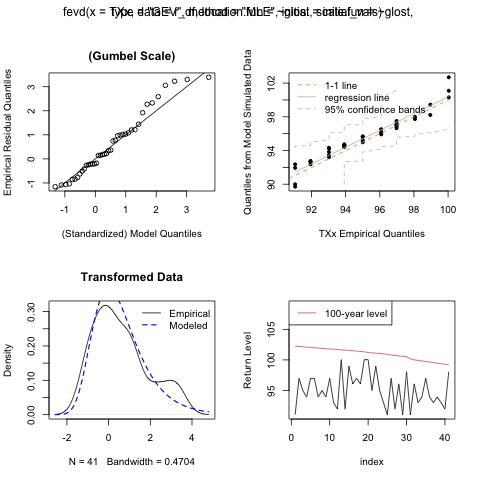

GEV model fitted: NclimGrid data


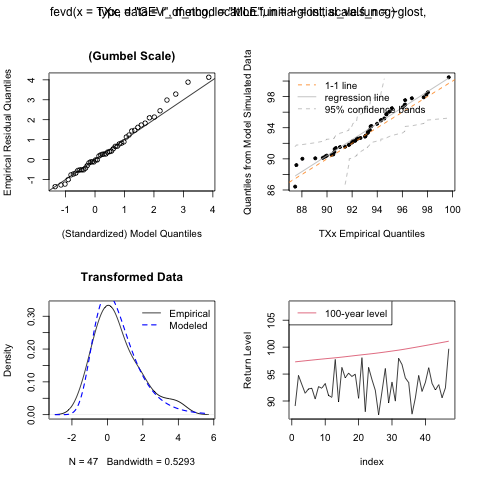

#########################################
Processing station PORT JERVIS, NY US at lon=-74.6905, lat=41.3891, elevation=177 m
Nearest valid NClimGrid point is at lon= -74.687496, lat= 41.39583468
#########################################


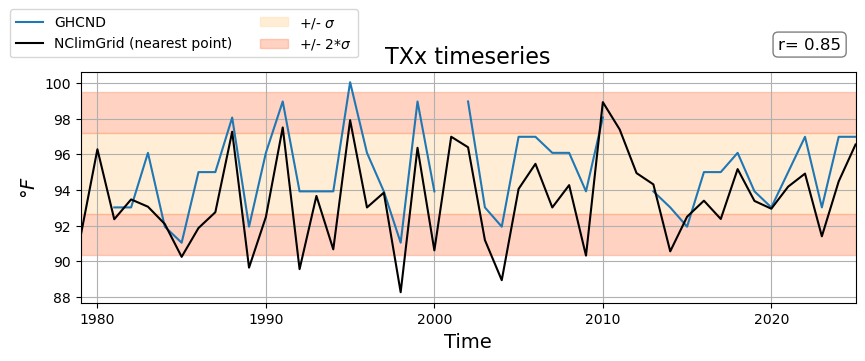

GEV model fitted: GHCND data


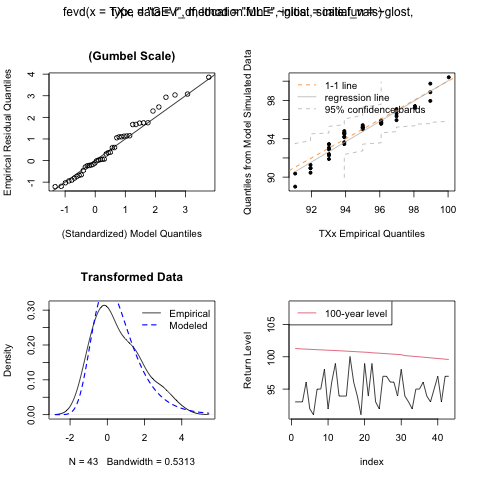

GEV model fitted: NclimGrid data


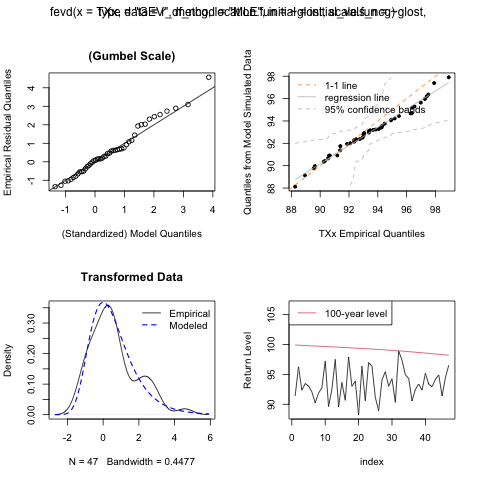

In [88]:

for ij in range(0,len(Tstations)):
  #for ij in range(2,3):
  ilon = longitude.sel(station = Tstations[ij]).data
  ilat = latitude.sel(station = Tstations[ij]).data
  # Extract values for boxes
  dsij = ds.sel(station = Tstations[ij])
  df = dsij.to_dataframe()
  df = df.reset_index()
  radius = 1.0 # degrees
  print('#########################################')  
  print(f'Processing station {dsij.name.data.item()} at lon={ilon}, lat={ilat}, elevation={elevation.sel(station = Tstations[ij]).data.item():.0f} m')

  x = dsij['time']
  y1 = dsij['TXx'].mean('time')-dsij['TXx'].std('time')
  y2 = dsij['TXx'].mean('time')+dsij['TXx'].std('time')
  y3 = dsij['TXx'].mean('time')-2*dsij['TXx'].std('time')
  y4 = dsij['TXx'].mean('time')+2*dsij['TXx'].std('time')
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,3))
  dsij['TXx'].plot(ax=ax, label='GHCND')
  if not dsae['TXx'].sel(lon=slice(ilon-radius, ilon+radius), lat=slice(ilat-radius, ilat+radius)).mean('time').isnull().all():
    valid_ncg = find_nearest_valid(dsae['TXx'], ilon, ilat, radius = radius)
    txx_ncg = valid_ncg.to_xarray()['TXx']
    lon_ncg=valid_ncg["lon"].values[0].item()
    lat_ncg=valid_ncg["lat"].values[0].item()
    print(f'Nearest valid NClimGrid point is at lon= {lon_ncg}, lat= {lat_ncg}')
  print('#########################################')  

  ax.plot(dsij['time'], txx_ncg, color='k', ls='-', linewidth=1.5, label='NClimGrid (nearest point)')  
  ax.fill_between(x, y1, y2, color='navajowhite', alpha=0.5,label='+/- $\sigma$')
  ax.fill_between(x, y2, y4, color='coral', alpha=0.35,label='+/- 2*$\sigma$')
  ax.fill_between(x, y1, y3, color='coral', alpha=0.35)
  ax.set_ylabel(f'{units}',fontsize=14)
  ax.set_xlabel('Time',fontsize=14)
  ax.grid()
  # set y axis lim
  ax.set_xlim(x.min(),x.max())
  # show legend
  ax.legend(loc='upper left',ncol=2,bbox_to_anchor=(-0.1,1.3),prop={'size': 10})
  ###
  mask = ~np.isnan(dsij['TXx'].values) & ~np.isnan(txx_ncg.values)
  correlation = np.corrcoef(dsij['TXx'].values[mask], txx_ncg.values[mask])[0, 1]
  ax.text(0.9, 1.15, f'r= {correlation:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
  ###
  ax.set_title(f'TXx timeseries',fontsize=16)
  plt.show()

  df_ncg = txx_ncg.to_dataframe().reset_index()
  df_ncg['time'] = df['time']
  df_ncg['glost'] = df['glost']

  df = df.assign(cell=1)
  # Remove zeros and NAN 
  # Remove timeseries with less than 15 data (as in Bilotta et al.)
  # Save rows removed
  dfsave = df[df['TXx'].isna()]
  df = df[df['TXx'].notna()]

  itime = df['time'].values
  ntime = len(itime)

  loc_init = df['TXx'].mean()
  scale_init = df['TXx'].std()
  shape_init = 0.01

  loc_init_ncg = df_ncg['TXx'].mean()
  scale_init_ncg = df_ncg['TXx'].std()

  glost = ann_glost.sel(time=slice(yearb,yeare)).to_dataframe().reset_index()
  dftime = np.arange(yearb,yeare+1)
  %R -i ntime,loc_init,scale_init,shape_init,glost
  %R -i df_ncg,loc_init_ncg,scale_init_ncg

  if df.empty == False: 
    # Convert xarray to pandas DataFrame to R data.frame
    # You can now work with 'r_df' in R

    with (ro.default_converter + pandas2ri.converter).context():
      r_df = ro.conversion.get_conversion().py2rpy(df)
      r_df_ncg = ro.conversion.get_conversion().py2rpy(df_ncg)
    globalenv['r_df'] = r_df
    globalenv['r_df_ncg'] = r_df_ncg
    #%R names(r_df)[names(r_df) == "time"] <- "year"
    # Extremes GEV model fitting  
    %R initial_vals <- list(location = loc_init, scale = scale_init, shape = shape_init)
    %R call_fevd <- paste("fevd(TXx, data = r_df,",fevd_options,")")
    %R m_gev <- eval(parse(text = call_fevd))
    print('GEV model fitted: GHCND data')
    %R plot(m_gev,rp=c(100))

    print('GEV model fitted: NclimGrid data')
    %R initial_vals_ncg <- list(location = loc_init_ncg, scale = scale_init_ncg, shape = shape_init)
    %R m_gev_ncg <- fevd(TXx, data = r_df_ncg, type='GEV', method='MLE', initial = initial_vals_ncg, location.fun = ~ glost, scale.fun = ~ glost)
    %R plot(m_gev_ncg,rp=c(100))



**Figure caption (per station).** Top figure: Annual Maximum Daily Temperature (TXx) time series for each GHCND station, with comparison to the NClimGrid nearest-neighbor point. Shaded bands represent ±1σ and ±2σ variability around the mean. The correlation coefficient between GHCND and NClimGrid TXx is displayed in the upper-right corner of each plot.
Bottom figure: Diagnostics from the GEV df fitted to the TXx data shown above. Quantile-quantile plot (top left) quantiles from a sample drawn from the fitted GEV df against the empirical data quantiles with 95% confidence bands (top right), density plots of empirical data and fitted GEV df (bottom left), and TXx are plotted as a line along with associated effective return levels for return periods of 100 years (bottom right).